In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = "/content/drive/MyDrive/AgriGuardian_Mbarara_Monthly_NDVI_Rainfall_2020_2024.csv"
df = pd.read_csv(file_path)

df.head()

,system:index,date,mean_ndvi,month,monthly_rainfall,year,.geo
0,0,2020-01,0.588014,1.0,76.876819,2020.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,2020-02,0.625046,2.0,42.176291,2020.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,2020-03,0.597979,3.0,100.178492,2020.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,2020-04,0.645683,4.0,180.225837,2020.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,2020-05,0.638144,5.0,36.737394,2020.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [3]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1wbi5Sf3jTvY_eLmqBqkaEnxtCg_qZf7elRE-TPQa4Es/edit#gid=0


In [4]:
# Keep only useful columns
df = df[["date", "mean_ndvi", "monthly_rainfall"]].copy()

# Replace missing placeholders with NaN
df["mean_ndvi"] = df["mean_ndvi"].replace(-9999, pd.NA)
df["monthly_rainfall"] = df["monthly_rainfall"].replace(-9999, pd.NA)

# Convert to numeric
df["mean_ndvi"] = pd.to_numeric(df["mean_ndvi"], errors="coerce")
df["monthly_rainfall"] = pd.to_numeric(df["monthly_rainfall"], errors="coerce")

# Convert date
df["date"] = pd.to_datetime(df["date"], format="%Y-%m")

# Drop missing rows
df = df.dropna().sort_values("date").reset_index(drop=True)

print(df.info())
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              55 non-null     datetime64[ns]
 1   mean_ndvi         55 non-null     float64       
 2   monthly_rainfall  55 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 1.4 KB
None


,date,mean_ndvi,monthly_rainfall
0,2020-01-01,0.588014,76.876819
1,2020-02-01,0.625046,42.176291
2,2020-03-01,0.597979,100.178492
3,2020-04-01,0.645683,180.225837
4,2020-05-01,0.638144,36.737394
5,2020-06-01,0.608557,28.155561
6,2020-07-01,0.450446,14.771678
7,2020-08-01,0.424315,56.788197
8,2020-09-01,0.461965,96.396073
9,2020-10-01,0.614472,189.771461


In [5]:
print("Number of rows after cleaning:", len(df))
print(df.tail())

Number of rows after cleaning: 55
         date  mean_ndvi  monthly_rainfall
50 2024-08-01   0.456720         51.694363
51 2024-09-01   0.449109         99.713830
52 2024-10-01   0.535470        125.667820
53 2024-11-01   0.686842        188.339435
54 2024-12-01   0.631447        103.360443


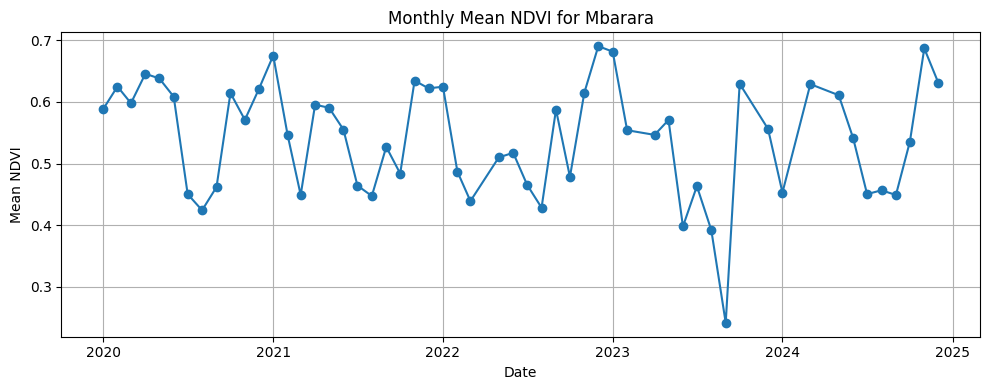

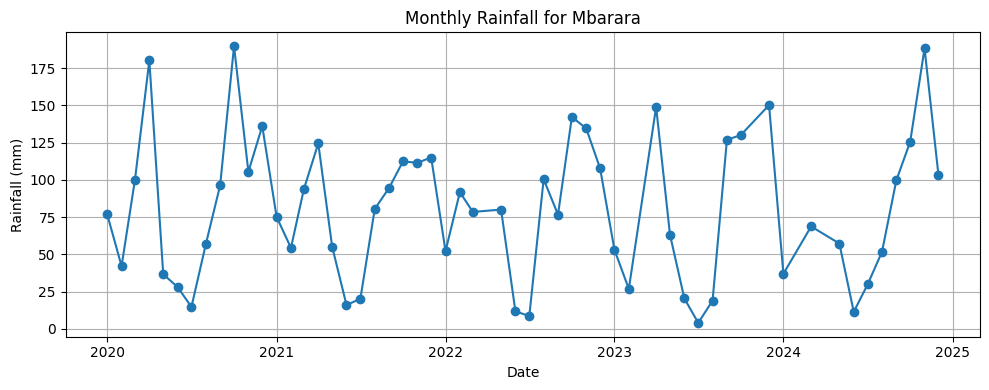

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["mean_ndvi"], marker="o")
plt.title("Monthly Mean NDVI for Mbarara")
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["monthly_rainfall"], marker="o")
plt.title("Monthly Rainfall for Mbarara")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
correlation = df["mean_ndvi"].corr(df["monthly_rainfall"])
print("Correlation between NDVI and rainfall:", correlation)

Correlation between NDVI and rainfall: 0.2817511838221328


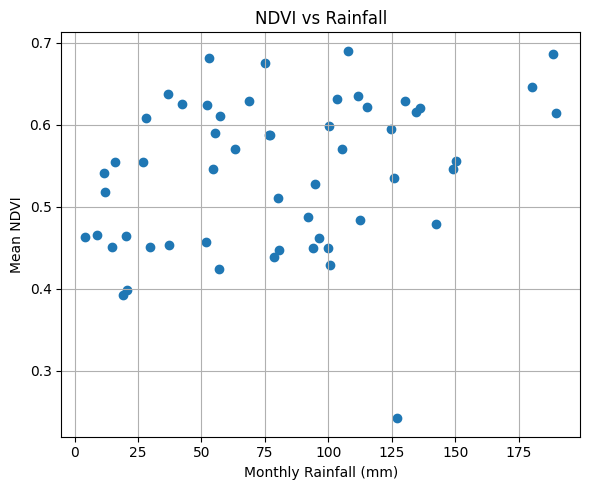

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(df["monthly_rainfall"], df["mean_ndvi"])
plt.xlabel("Monthly Rainfall (mm)")
plt.ylabel("Mean NDVI")
plt.title("NDVI vs Rainfall")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
df["ndvi_next"] = df["mean_ndvi"].shift(-1)
df["stress_next_month"] = (df["ndvi_next"] < df["mean_ndvi"]).astype(int)

df = df.dropna().reset_index(drop=True)

df[["date", "mean_ndvi", "ndvi_next", "stress_next_month"]].head(10)

,date,mean_ndvi,ndvi_next,stress_next_month
0,2020-01-01,0.588014,0.625046,0
1,2020-02-01,0.625046,0.597979,1
2,2020-03-01,0.597979,0.645683,0
3,2020-04-01,0.645683,0.638144,1
4,2020-05-01,0.638144,0.608557,1
5,2020-06-01,0.608557,0.450446,1
6,2020-07-01,0.450446,0.424315,1
7,2020-08-01,0.424315,0.461965,0
8,2020-09-01,0.461965,0.614472,0
9,2020-10-01,0.614472,0.570964,1


In [10]:
df["ndvi_prev_1"] = df["mean_ndvi"].shift(1)
df["rain_prev_1"] = df["monthly_rainfall"].shift(1)
df["ndvi_prev_2"] = df["mean_ndvi"].shift(2)
df["rain_prev_2"] = df["monthly_rainfall"].shift(2)

df = df.dropna().reset_index(drop=True)

df.head()

,date,mean_ndvi,monthly_rainfall,ndvi_next,stress_next_month,ndvi_prev_1,rain_prev_1,ndvi_prev_2,rain_prev_2
0,2020-03-01,0.597979,100.178492,0.645683,0,0.625046,42.176291,0.588014,76.876819
1,2020-04-01,0.645683,180.225837,0.638144,1,0.597979,100.178492,0.625046,42.176291
2,2020-05-01,0.638144,36.737394,0.608557,1,0.645683,180.225837,0.597979,100.178492
3,2020-06-01,0.608557,28.155561,0.450446,1,0.638144,36.737394,0.645683,180.225837
4,2020-07-01,0.450446,14.771678,0.424315,1,0.608557,28.155561,0.638144,36.737394


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols = [
    "mean_ndvi",
    "monthly_rainfall",
    "ndvi_prev_1",
    "rain_prev_1",
    "ndvi_prev_2",
    "rain_prev_2"
]

X = df[feature_cols]
y = df["stress_next_month"]

# Time-based split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6363636363636364

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.67      0.86      0.75         7

    accuracy                           0.64        11
   macro avg       0.58      0.55      0.54        11
weighted avg       0.61      0.64      0.60        11


Confusion Matrix:

[[1 3]
 [1 6]]


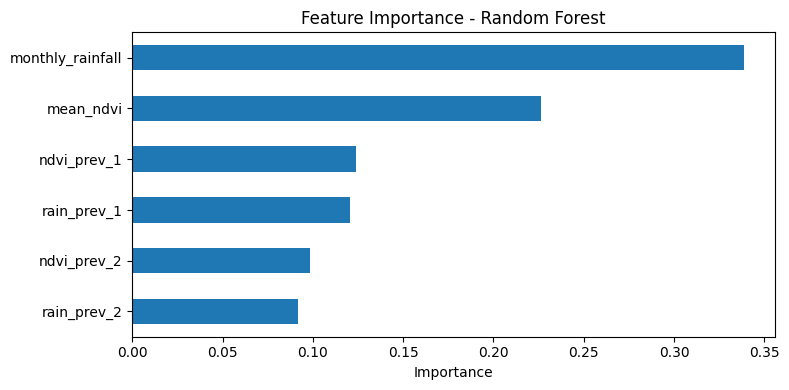

In [12]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 4))
importance.plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

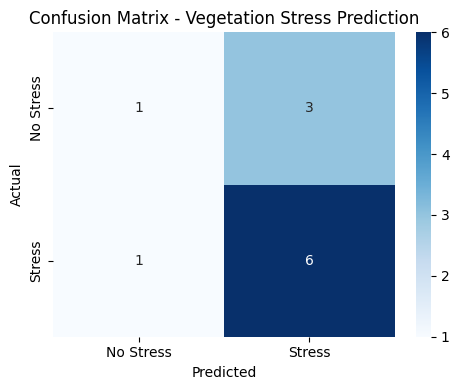

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stress", "Stress"],
    yticklabels=["No Stress", "Stress"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Vegetation Stress Prediction")

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

# Rebuild clean base table
df = df.copy()
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

# Monthly climatology (mean per calendar month)
monthly_climatology = df.groupby("month")[["mean_ndvi", "monthly_rainfall"]].mean().rename(
    columns={
        "mean_ndvi": "ndvi_climatology",
        "monthly_rainfall": "rainfall_climatology"
    }
)

df = df.merge(monthly_climatology, on="month", how="left")

# Anomalies = current value - long-term monthly mean
df["ndvi_anomaly"] = df["mean_ndvi"] - df["ndvi_climatology"]
df["rainfall_anomaly"] = df["monthly_rainfall"] - df["rainfall_climatology"]

df.head(12)

,date,mean_ndvi,monthly_rainfall,ndvi_next,stress_next_month,ndvi_prev_1,rain_prev_1,ndvi_prev_2,rain_prev_2,month,year,ndvi_climatology,rainfall_climatology,ndvi_anomaly,rainfall_anomaly
0,2020-03-01,0.597979,100.178492,0.645683,0,0.625046,42.176291,0.588014,76.876819,3,2020,0.528803,85.354815,0.069177,14.823677
1,2020-04-01,0.645683,180.225837,0.638144,1,0.597979,100.178492,0.625046,42.176291,4,2020,0.595924,151.227720,0.049759,28.998117
2,2020-05-01,0.638144,36.737394,0.608557,1,0.645683,180.225837,0.597979,100.178492,5,2020,0.584101,58.519444,0.054043,-21.782049
3,2020-06-01,0.608557,28.155561,0.450446,1,0.638144,36.737394,0.645683,180.225837,6,2020,0.524123,17.600842,0.084435,10.554719
4,2020-07-01,0.450446,14.771678,0.424315,1,0.608557,28.155561,0.638144,36.737394,7,2020,0.458870,15.533395,-0.008423,-0.761716
5,2020-08-01,0.424315,56.788197,0.461965,0,0.450446,14.771678,0.608557,28.155561,8,2020,0.429837,61.697333,-0.005522,-4.909136
6,2020-09-01,0.461965,96.396073,0.614472,0,0.424315,56.788197,0.450446,14.771678,9,2020,0.453495,98.880862,0.008470,-2.484790
7,2020-10-01,0.614472,189.771461,0.570964,1,0.461965,96.396073,0.424315,56.788197,10,2020,0.548357,140.047485,0.066115,49.723976
8,2020-11-01,0.570964,105.499887,0.620766,0,0.614472,189.771461,0.461965,96.396073,11,2020,0.626884,134.976448,-0.055921,-29.476561
9,2020-12-01,0.620766,136.137909,0.675289,0,0.570964,105.499887,0.614472,189.771461,12,2020,0.622408,127.281641,-0.001642,8.856268


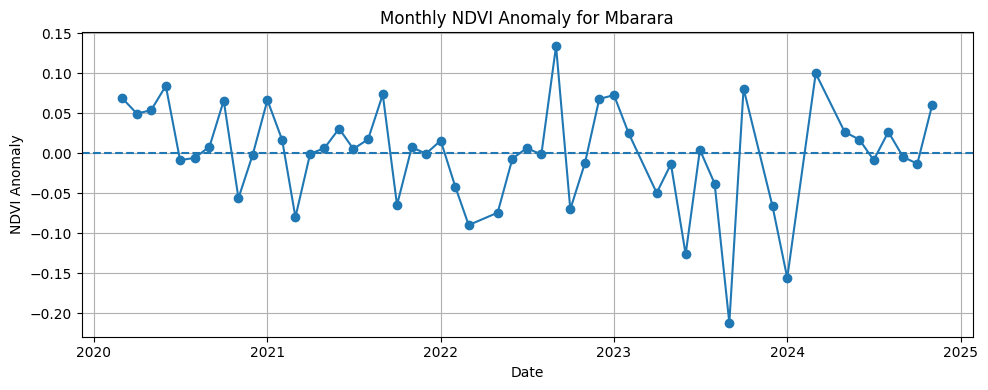

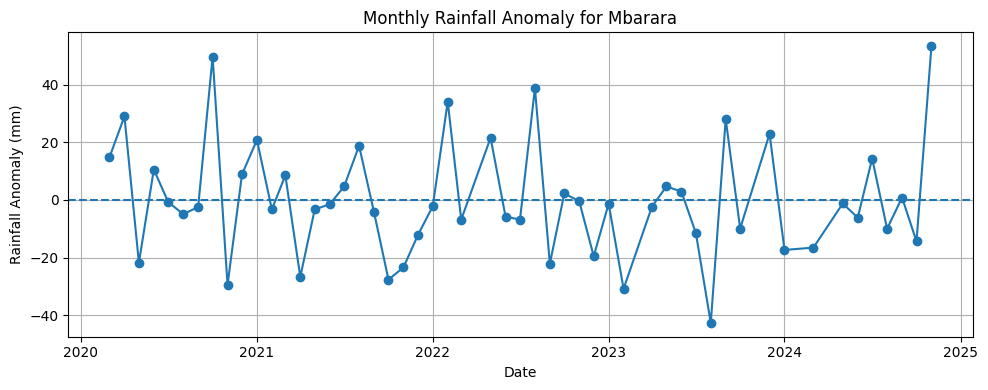

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["date"], df["ndvi_anomaly"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Monthly NDVI Anomaly for Mbarara")
plt.xlabel("Date")
plt.ylabel("NDVI Anomaly")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df["date"], df["rainfall_anomaly"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Monthly Rainfall Anomaly for Mbarara")
plt.xlabel("Date")
plt.ylabel("Rainfall Anomaly (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
df = df.copy()

df["ndvi_next"] = df["mean_ndvi"].shift(-1)
df["ndvi_change_next"] = df["ndvi_next"] - df["mean_ndvi"]

# Significant decline threshold
df["stress_next_month"] = (df["ndvi_change_next"] < -0.02).astype(int)

df[["date", "mean_ndvi", "ndvi_next", "ndvi_change_next", "stress_next_month"]].head(12)

,date,mean_ndvi,ndvi_next,ndvi_change_next,stress_next_month
0,2020-03-01,0.597979,0.645683,0.047704,0
1,2020-04-01,0.645683,0.638144,-0.007539,0
2,2020-05-01,0.638144,0.608557,-0.029587,1
3,2020-06-01,0.608557,0.450446,-0.158111,1
4,2020-07-01,0.450446,0.424315,-0.026131,1
5,2020-08-01,0.424315,0.461965,0.037649,0
6,2020-09-01,0.461965,0.614472,0.152507,0
7,2020-10-01,0.614472,0.570964,-0.043508,1
8,2020-11-01,0.570964,0.620766,0.049803,0
9,2020-12-01,0.620766,0.675289,0.054523,0


In [17]:
df["ndvi_prev_1"] = df["mean_ndvi"].shift(1)
df["rain_prev_1"] = df["monthly_rainfall"].shift(1)
df["ndvi_prev_2"] = df["mean_ndvi"].shift(2)
df["rain_prev_2"] = df["monthly_rainfall"].shift(2)

df["ndvi_anom_prev_1"] = df["ndvi_anomaly"].shift(1)
df["rain_anom_prev_1"] = df["rainfall_anomaly"].shift(1)

# Optional rolling means
df["ndvi_roll_3"] = df["mean_ndvi"].rolling(3).mean()
df["rain_roll_3"] = df["monthly_rainfall"].rolling(3).mean()

df = df.dropna().reset_index(drop=True)

print("Rows after feature engineering:", len(df))
df.head()

Rows after feature engineering: 49


,date,mean_ndvi,monthly_rainfall,ndvi_next,stress_next_month,ndvi_prev_1,rain_prev_1,ndvi_prev_2,rain_prev_2,month,year,ndvi_climatology,rainfall_climatology,ndvi_anomaly,rainfall_anomaly,ndvi_change_next,ndvi_anom_prev_1,rain_anom_prev_1,ndvi_roll_3,rain_roll_3
0,2020-05-01,0.638144,36.737394,0.608557,1,0.645683,180.225837,0.597979,100.178492,5,2020,0.584101,58.519444,0.054043,-21.782049,-0.029587,0.049759,28.998117,0.627269,105.713908
1,2020-06-01,0.608557,28.155561,0.450446,1,0.638144,36.737394,0.645683,180.225837,6,2020,0.524123,17.600842,0.084435,10.554719,-0.158111,0.054043,-21.782049,0.630795,81.706264
2,2020-07-01,0.450446,14.771678,0.424315,1,0.608557,28.155561,0.638144,36.737394,7,2020,0.458870,15.533395,-0.008423,-0.761716,-0.026131,0.084435,10.554719,0.565716,26.554878
3,2020-08-01,0.424315,56.788197,0.461965,0,0.450446,14.771678,0.608557,28.155561,8,2020,0.429837,61.697333,-0.005522,-4.909136,0.037649,-0.008423,-0.761716,0.494440,33.238479
4,2020-09-01,0.461965,96.396073,0.614472,0,0.424315,56.788197,0.450446,14.771678,9,2020,0.453495,98.880862,0.008470,-2.484790,0.152507,-0.005522,-4.909136,0.445575,55.985316


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols = [
    "mean_ndvi",
    "monthly_rainfall",
    "ndvi_anomaly",
    "rainfall_anomaly",
    "ndvi_prev_1",
    "rain_prev_1",
    "ndvi_prev_2",
    "rain_prev_2",
    "ndvi_anom_prev_1",
    "rain_anom_prev_1",
    "ndvi_roll_3",
    "rain_roll_3"
]

X = df[feature_cols]
y = df["stress_next_month"]

# Chronological split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("Improved Model Accuracy:", accuracy_score(y_test, y_pred2))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred2))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred2))

Improved Model Accuracy: 0.7

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.60      0.75      0.67         4

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70        10


Confusion Matrix:

[[4 2]
 [1 3]]


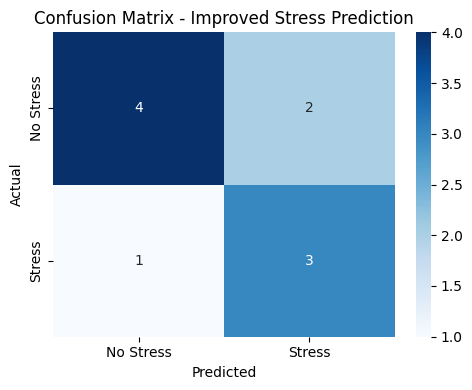

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stress", "Stress"],
    yticklabels=["No Stress", "Stress"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Improved Stress Prediction")
plt.tight_layout()
plt.show()

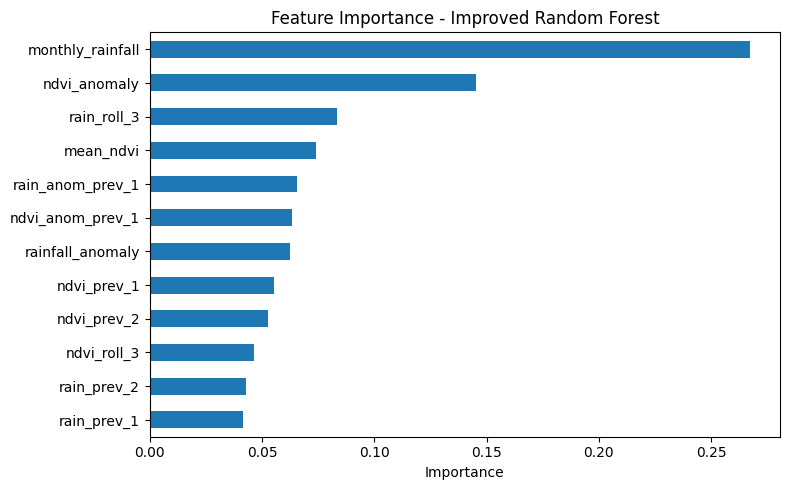

In [20]:
importance2 = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8,5))
importance2.plot(kind="barh")
plt.title("Feature Importance - Improved Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [21]:
baseline_accuracy = 0.6363636363636364  # your first result
improved_accuracy = accuracy_score(y_test, y_pred2)

comparison = pd.DataFrame({
    "Model": ["Baseline Random Forest", "Improved Random Forest"],
    "Accuracy": [baseline_accuracy, improved_accuracy]
})

comparison

,Model,Accuracy
0,Baseline Random Forest,0.636364
1,Improved Random Forest,0.700000


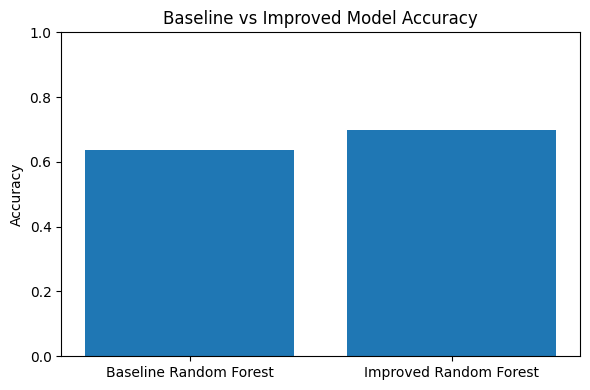

In [22]:
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Baseline vs Improved Model Accuracy")
plt.tight_layout()
plt.show()